# 5. Prefix Caching

글쓴이: [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)), [Claude Code](https://claude.com/claude-code) 🤖

지난 세 강의는 prefill을 반드시 해야 하는 일로 다뤘습니다. Compute-bound이고(1강),
decode를 방해하며(3강), 잘게 쪼개거나 전용 GPU로 옮길 수 있었죠(4강). 이 강의는 그
prefill 중 일부를 아예 하지 않는 방법에 대한 것입니다.

## 왜 같은 token이 반복해서 도착하는가

LLM은 건네준 token들의 순수 함수입니다. 서버는 적어도 가장 단순한 형태에서는 요청
사이에 아무것도 기억하지 않습니다. 그래서 모델이 지금까지의 대화를 알아야 하는
chatbot에서는, 지난 대화를 그냥 새 질문 앞에 붙여 보냅니다. 모델은 매번 전체 기록과
질문을 함께 읽습니다.

그래서 메시지 두 개짜리 대화는 작은 요청 두 개가 아닙니다. 작은 요청 하나와 큰 요청
하나이고, 실제로 선을 타고 가는 것은 이렇게 생겼습니다:

```text
request 1   [system prompt, ~1,000 tokens]
            [user: "How do I reverse a list in Python?"]

response 1  [assistant: "Use list.reverse(), or ..."]

request 2   [system prompt, ~1,000 tokens]            <- identical
            [user: "How do I reverse a list in Python?"]   <- identical
            [assistant: "Use list.reverse(), or ..."]      <- identical
            [user: "What about a tuple?"]                  <- new
```

**System prompt**는 application이 모든 대화 앞에 붙이면서 사용자에게는 절대 보여 주지
않는 텍스트 덩어리입니다. 이 assistant가 누구여야 하는지, 무엇을 거절해야 하는지, 오늘
날짜가 며칠인지, 호출할 수 있는 각 tool의 JSON schema는 무엇인지, 그리고 종종 좋은 답변의
예시 몇 개까지 들어 있습니다. 제대로 된 application에서는 짧지 않습니다. 수백에서 수천
token이고, tool 정의를 열댓 개 들고 다니는 agent라면 훨씬 깁니다(6강).

첫 번째 요청은 system prompt와 사용자의 질문을 prefill합니다. 두 번째는 system prompt,
첫 질문, 첫 답변, *그리고* 두 번째 질문을 prefill합니다. 첫 번째 주고받음을 들고 가야
하는 이유는 그러지 않으면 모델이 그것을 볼 수 없기 때문입니다. "What about a tuple?"은
위의 질문과 답변 없이는 아무 의미가 없죠. Prompt는 대화가 이어지는 내내 이렇게 계속
자라고, 그 대부분은 모델이 이미 처리한 적 있는 텍스트입니다.

### 같은 텍스트는 사용자들 사이에서도 반복된다

반복은 한 대화 안에만 있는 것이 아닙니다. LLM 기반 application이 보내는 *모든* 요청 앞에
같은 system prompt가 붙으므로, 서로 아무 상관 없는 사용자들이 보낸 요청이라도 앞쪽 천
token은 token 단위로 똑같습니다.

그 텍스트가 실제로 무엇인지 보면 이해가 쉽습니다. 아래 발췌는 6강에서 뜯어볼 오픈소스
multi-agent 시스템 [OWL](https://github.com/camel-ai/owl)
([Hu et al., NeurIPS '25](https://arxiv.org/abs/2505.23885))의 기록된 trace를 디코딩한
것입니다. 표시한 곳을 생략했을 뿐, 실제로 모델에 보낸 그대로입니다. 이 시스템의 web-search
worker가 보내는 모든 요청은 다음 **system prompt**로 시작합니다:

```text
You are a helpful assistant that can search the web, extract webpage content,
simulate browser actions, and provide relevant information to solve the given task.
Keep in mind that:
- Do not be overly confident in your own knowledge. Searching can provide a
  broader perspective and help validate existing knowledge.
- If the search snippet is unhelpful but the URL comes from an authoritative
  source, try visit the website for more details.
- When looking for specific numerical values (e.g., dollar amounts), prioritize
  reliable sources and avoid relying only on search snippets.
- When solving tasks that require web searches, check Wikipedia first before
  exploring other websites.
[...]
```

바로 아래에는 **tool 정의**가 옵니다. 이 worker가 호출할 수 있는 tool 여덟 개 각각의
이름, 설명, 인자 schema입니다. 그중 둘만 보면:

```text
namespace functions {

// Use Google search engine to search information for the given query.
type search_google = (_: {
// The query to be searched.
query: string,
// The number of result pages to retrieve.
num_result_pages: number,
}) => any;

// Search the entity in WikiPedia and return the summary of the required page,
// containing factual information about the given entity.
type search_wiki = (_: {
// The entity to be searched.
entity: string,
}) => any;

[... six more ...]
}
```

역할이 다른 OWL의 planner는 대신, 자기가 내려야 할 판단에 대한 **예시**를 한 페이지씩
들고 다닙니다. Classifier가 모든 입력 앞에 붙이는 few-shot 예시의 agent 버전인 셈이죠:

```text
Here are some scenarios where using code is the preferred approach:
1. Tasks requiring access to a large number of webpages. Example: "How many times
   was a Twitter/X post cited as a reference on English Wikipedia pages for each
   day of August in the last June 2023 versions of the pages?" Reason: Manually
   checking each Wikipedia page would be highly inefficient, while Python code can
   systematically fetch and process the required data.
2. Data processing involving complex filtering or calculations. Example: "Analyze
   all article titles on Hacker News in March 2024 and find the top 10 most
   frequently occurring keywords." Reason: This task requires processing a large
   amount of text data, which is best handled programmatically.
[...]
```

Agent가 웹 검색이 필요할 때마다, web-search worker에게 보내는 요청은 실제 할 일이
언급되기도 전에 위와 같은 텍스트 약 1,500 token으로 시작합니다.

여러 사람이 같은 문서에 대해 물을 때도 공통 prefix가 생깁니다. 같은 매뉴얼, 계약서,
저장소 파일을 매번 다른 질문 위에 붙여 보내는 경우죠.
[vLLM 문서](https://docs.vllm.ai/en/latest/features/automatic_prefix_caching/)는 바로
이것을 prefix caching을 켜는 대표적인 사례로 듭니다.

Kimi chatbot을 떠받치는 serving system인 Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079))는 운영 trace에서, cache에
자리가 있을 때 전체 prompt token의 대략 절반이 재사용 가능하다고 보고합니다. 대화형
트래픽에서는 약 40%(대부분 사용자 자신의 기록을 재사용), tool과 agent 성격의 트래픽에서는
약 59%(길고 반복적인 system prompt가 사용자들 사이에서 재사용)입니다. 같은 배포에서 cache에
자리가 없는 피크 시간에는 hit rate가 20% 아래로 떨어집니다. 이 효과는 이 강의 뒷부분에서
재현해 봅니다.

## 아이디어

**Prefix caching**은 그 KV cache(뒤따르는 모든 token이 attend하는, token별 key와 value,
2강)를 요청이 끝난 뒤에도 남겨 두었다가 재사용합니다. 새 prompt가 KV가 아직 남아 있는
token들로 시작하면, 그 token들은 다시 prefill하지 않습니다. 모델은 과거의 KV를 재사용하고,
한 번도 본 적 없는 token의 KV만 계산합니다. 정확도에는 아무 대가가 없습니다. 한 token의
KV는 그 앞의 token들에만 의존하므로, 재사용한 block에는 새로 prefill했어도 나왔을 값이
정확히 들어 있습니다.

:::{admonition} 학습 목표
- KV cache가 block hash로 주소를 얻는 방식과, 재사용이 왜 *prefix*에서만 되는지 설명할 수
  있다.
- 한 대화 안에서, 그리고 긴 preamble을 공유하는 사용자들 사이에서 prefix caching이 prefill
  작업량과 TTFT에 주는 효과를 측정할 수 있다.
- Hit를 망가뜨리는 것들을 설명할 수 있다: 공유 텍스트 앞에 놓인 가변 텍스트, 그리고 메모리
  압박에 따른 eviction.
- Cache 친화적으로 prompt를 배치할 수 있다.
- 실제 배포에서 캐시된 block이 어디에 사는지 말할 수 있다.
:::

## 준비

3강, 4강과 같은 시스템입니다. A100 두 장 위의 replica 하나에서 도는
Qwen2.5-32B-Instruct.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


## Prefix cache는 어떻게 동작하나

### 1단계: KV cache는 이미 page 단위다

KV cache가 메모리에 어떻게 놓이는지는 아직 보지 않았습니다. 요청마다 하나의 연속된
배열이 아니라, **block**(page라고도 합니다) 단위로 저장됩니다. 가상 메모리의 page를
떠올리면 됩니다. KV cache를 block 단위로 저장하는 아이디어는 vLLM이 그 위에 세워진 논문인
**PagedAttention** ([Kwon et al., SOSP '23](https://arxiv.org/abs/2309.06180))에서
나왔습니다.

Block 크기는 설정할 수 있습니다. vLLM은 16 token이 기본이고(`--block-size`),
TensorRT-LLM은 32, SGLang은 1입니다(`--page-size`). Block이 크면 token당 관리 비용이 줄고
block을 메모리 사이에서 옮길 때 효율이 좋습니다. 작으면 마지막 부분 block에서 낭비되는
자리가 줄고, 다음 단계에서 보듯 prefix를 더 정밀하게 맞출 수 있습니다. 우리 실습은 16을
씁니다.

### 2단계: 모든 block에 이름을 붙인다

Prefix caching은 그 위에 아이디어 하나를 더합니다. **꽉 찬 모든 block에 이름을 붙이고,
이름에서 block으로 가는 표를 유지하는 것**입니다. 이름은 다음의 해시입니다:

```text
hash(block) = H( hash(이전 block), 이 block의 token id 16개 )
```

그래서 block의 이름은 자기 token뿐 아니라 *그 앞의 모든 기록*에도 의존합니다. 두 요청의
5번째 block 이름이 같으려면, 앞의 80 (16$\times$5) token이 똑같아야 합니다.

요청이 도착하면 scheduler는 prompt를 block 단위로 해시해서 이름을 하나씩 찾아보다가, 처음
실패하는 지점에서 멈춥니다. 그 앞까지가 전부 **hit**입니다. 그 block들은 재사용되고(참조
횟수가 올라가 쓰는 동안에는 evict되지 않습니다), 요청은 캐시되지 않은 첫 token부터
prefill을 시작합니다.

```text
  turn 1 prompt   [sys ][sys ][user1]                 block 3개 계산,
                                     [ans1]           decode 중에 1개 더 채워짐
  turn 2 prompt   [sys ][sys ][user1][ans1][user2]    4개 hit, 1개 계산
```

답변의 block도 재사용된다는 점에 주의하세요. 그 block들은 turn 1의 decode 중에 쓰였고 다른
것들과 똑같이 이름이 붙었습니다. 그래서 turn 2는 앞선 prompt뿐 아니라 앞선 답변도
재사용합니다.

여기서 세 가지 성질이 따라 나오고, 셋 다 실전에서 중요합니다:

1. **Substring이 아니라 prefix로 맞춥니다.** 해시가 사슬처럼 엮여 있어서, prompt 앞쪽의
   token 하나만 달라도 뒤의 모든 block 이름이 달라집니다. 나머지 텍스트가 똑같아도요.
   맨 처음부터 연속으로 똑같은 token들만 hit로 칩니다.
2. **마지막 부분 block에는 이름이 없습니다.** 꽉 찬 block만 해시하므로, hit는 block 크기의
   배수로 내림됩니다. 대체로 무시해도 되는 작은 부작용이고, block 크기가 클 때만
   문제가 되는데 보통은 크지 않습니다.
3. **캐시된 block은 실행 중인 요청과 메모리를 두고 경쟁합니다.** 캐시된 prefix와 실행 중인
   요청의 KV cache는 같은 pool에 있습니다. 그래서 요청이 자리를 더 필요로 하면 서버는
   무언가를 내보내야 하고, 자연스러운 후보는 실행 중인 요청이 쓰지 않는 block, 즉 정확히
   캐시된 prefix입니다. 한 번 evict된 prefix는 나중에 딱 맞는 요청이 와도 재사용할 수
   없습니다.

### 같은 아이디어, 다른 자료구조

"내가 이미 가진 prefix가 무엇인가"에 답하는 방법이 flat hash table만 있는 것은 아닙니다.
SGLang은 token id에 대한 **radix tree**로 들고 있습니다. 관심 있으면 *RadixAttention*
논문 ([Zheng et al., NeurIPS '24](https://arxiv.org/abs/2312.07104))을 읽어 보세요.
우리 simulator는 vLLM의 해시 block 방식을 구현합니다.

### 캐시된 block은 어디에 사는가

우리 simulator는 KV cache와 prefix cache가 GPU 메모리에 있는 가장 단순한 설계를
simulation합니다. GPU 메모리가 꽉 차면 무언가를 내보내야 하죠. 실제 시스템은 훨씬 복잡할 수
있습니다. vLLM은 block을 CPU 메모리로 offload할 수 있고,
[LMCache](https://github.com/LMCache/LMCache)는 로컬과 원격 backend를 갖춘 재사용 가능한
KV 저장소를 더합니다. Kimi chatbot을 서비스하는 Mooncake
([Qin et al., FAST '25](https://arxiv.org/abs/2407.00079))는 가장 멀리 갑니다. KV cache가
CPU DRAM, SSD, 심지어 원격 노드에 있을 수도 있습니다.
이렇게 복잡한 구성에서는 요청을 해당 KV가 있는 노드로 보내거나, 아니면 CPU DRAM, SSD,
원격 노드에서 네트워크로 KV를 끌어와야 하고, 그만큼 추가 오버헤드가 생깁니다.
그렇게 하는 편이 여전히 이득일 때도 있고, 그냥 prefill을 다시 하는 편이 나을 때도 있습니다.

## 여러 turn짜리 workload

대화 trace를 만들어 봅시다. 각 session은 사용자와 assistant가 번갈아 가는 것입니다.
200 token짜리 사용자 메시지, 200 token짜리 답변, 그다음 또 사용자 메시지가 앞의 모든 것
뒤에 붙고, 하는 식이죠. Turn *k+1*은 turn *k*가 끝난 뒤(`dep`)에야, 그리고 사람이 답변을
읽는 시간을 대신하는 **think time**을 더한 뒤에 풀립니다.

Prefix cache가 어떻게 동작하는지 simulation하려면 *token id*가 필요합니다. (기억하세요,
똑같은 token id 나열만 prefix hit를 만듭니다!) 그래서 이 강의의 trace에는 1–4강처럼 길이만
적는 대신 `token_ids` 열이 들어 있습니다. `lsg.simulate`에서 prefix caching은 기본으로 꺼져
있고 `prefix_caching=True`로 켭니다. 요청의 token id는 무작위로 만들어서, prefix cache hit가
우리가 의도한 곳에서만 일어나도록 합니다.

단순함을 위해 system prompt는 모델링하지 않습니다. Turn 0의 prompt는 사용자의 질문뿐이고,
따라서 두 요청이 공유할 수 있는 것은 한 대화의 기록뿐입니다. 공유 preamble(system prompt)은
다음 실험에서 다룹니다.

이것은 또한 일부러 깔끔하게 만든 workload입니다. Turn 길이가 고정되어 있고, 매 turn이 앞의
것에 덧붙기만 하며, 우연히 맞는 것은 아무것도 없습니다. 실제 대화는 더 지저분합니다. Turn
길이가 제각각이고, 사용자가 메시지를 수정하거나 다시 생성하면(기록이 바뀌어 prefix가 날아
갑니다), client가 context 한도에 맞추려고 오래된 turn을 잘라 냅니다(prompt의 *앞부분*이
바뀌는, 가장 나쁜 변경입니다). 아래의 KV cache hit rate는 기대할 숫자가 아니라 효과의 모양으로
읽으세요. 6강에서는 기록된 agent workload에서 60%를 측정합니다.

In [2]:
rng = np.random.default_rng(0)
def toks(n):
    """n token ids that appear nowhere else (so nothing matches by accident)."""
    return rng.integers(10, 150_000, n).tolist()

def chat_trace(n_sessions=24, n_turns=6, question=200, answer=200, preamble=0,
               preamble_first=True, think=5.0, name=None):
    """Multi-turn conversations, optionally sharing a `preamble`-token system prompt."""
    shared = toks(preamble)
    rows = []
    for s in range(n_sessions):
        context = []
        for t in range(n_turns):
            user = toks(question)
            # Turn 0 starts the conversation; later turns append to the context.
            context = (shared + user if preamble_first else user + shared) if t == 0 \
                      else context + user
            reply = toks(answer)
            rows.append(dict(prefill=len(context), decode=answer, ids=context + reply,
                             session=s, turn=t, dep=[] if t == 0 else [t - 1],
                             think=0.0 if t == 0 else think, rid=1000 * s + t))
            context = context + reply    # the next turn sees this answer too
    df = pd.DataFrame(rows)
    path = lsg.make_trace(df.prefill, df.decode, len(df), name=name, token_ids=df.ids,
                          session_id=df.session, turn_id=df.turn, dep=df.dep,
                          think_time=df.think, request_id=df.rid)
    return path, df

chat, chat_df = chat_trace()
chat_df[["session", "turn", "prefill", "decode", "think"]].head(7)

,session,turn,prefill,decode,think
0,0,0,200,200,0.0
1,0,1,600,200,5.0
2,0,2,1000,200,5.0
3,0,3,1400,200,5.0
4,0,4,1800,200,5.0
5,0,5,2200,200,5.0
6,1,0,200,200,0.0


Turn 0은 200 token을 prefill하고, 이후 모든 turn은 앞 turn보다 400 token을 더
prefill합니다. 사용자의 새 메시지와 assistant의 직전 답변이죠. 새로운 것은 그 400개뿐이고,
나머지는 몇 초 전에 이 replica에서 계산한 것입니다.

## 효과가 있을까?

같은 trace를 prefix caching을 끄고, 켜고 돌려 봅시다.

In [3]:
def run(trace, df, **kwargs):
    return lsg.simulate(**SYSTEM, trace=trace, num_requests=len(df), **kwargs)

cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)",
        "total execution time (s)"]
runs = {f"prefix caching {'on' if pc else 'off'}": run(chat, chat_df, qps=1.0, prefix_caching=pc)
        for pc in (False, True)}
pd.DataFrame({k: {**r.summary()[cols], "prompt tokens computed": r.requests["request_num_prefill_tokens"].sum()
                                       - r.requests["request_num_prefill_tokens_cached"].sum(),
                  "KV cache hit rate": r.cache_hit_rate}
              for k, r in runs.items()}).round(2)

,prefix caching off,prefix caching on
TTFT p50 (ms),351.94,84.54
TTFT p99 (ms),1966.43,123.36
TPOT p50 (ms),49.08,40.22
throughput (tok/s),1738.30,1949.51
total execution time (s),115.98,103.41
prompt tokens computed,172800.00,28800.00
KV cache hit rate,0.00,0.83


전체 prompt token의 83%는 prefill이 아예 필요 없습니다. 앞선 turn의 KV cache를 그대로
재사용하면 되니까요. 중앙값 TTFT는 약 350 ms에서 85 ms로 떨어지고, tail은 16분의 1이
됩니다. Cache hit는 기다림도 대부분 없애 줍니다. 건너뛴 prefill이 원래라면 뒤에 선 모든
요청을 늦췄을 테니까요.

TPOT도 좋아지는데, 3강에서 본 이유 때문입니다. Prefill이 짧아지면 decode 옆에 큰 prefill
chunk를 싣고 가는 step이 줄어듭니다.

이득이 대화 전체에 고르게 퍼지는 것은 아닙니다. Turn별로 봅시다.

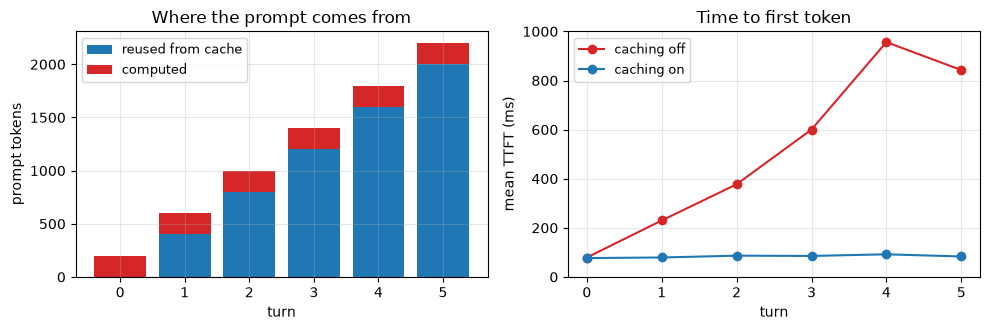

In [4]:
hit = runs["prefix caching on"].requests.copy()
hit["turn"] = hit["Request Id"] % 1000
per_turn = hit.groupby("turn").agg(prompt=("request_num_prefill_tokens", "mean"),
                                   cached=("request_num_prefill_tokens_cached", "mean"),
                                   ttft=("prefill_e2e_time", "mean"))
miss = runs["prefix caching off"].requests.copy()
miss["turn"] = miss["Request Id"] % 1000
per_turn["ttft_off"] = miss.groupby("turn")["prefill_e2e_time"].mean()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(per_turn.index, per_turn["cached"], label="reused from cache", color="C0")
ax[0].bar(per_turn.index, per_turn["prompt"] - per_turn["cached"],
          bottom=per_turn["cached"], label="computed", color="C3")
ax[0].set(xlabel="turn", ylabel="prompt tokens", title="Where the prompt comes from")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft_off"], "o-", color="C3", label="caching off")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft"], "o-", color="C0", label="caching on")
ax[1].set(xlabel="turn", ylabel="mean TTFT (ms)", title="Time to first token", ylim=(0, None))
for a in ax:
    a.legend(fontsize=9)
fig.tight_layout()

Caching이 없으면 대화는 turn이 지날수록 비싸집니다. Prompt가 자라니 TTFT도 자라죠.
Caching이 있으면 prompt에서 *계산되는* 부분이 평평합니다. 언제나 새로운 400 token뿐이고,
따라서 TTFT도 평평합니다.

(Turn 0은 예외입니다. Prompt가 처음 보는 것이라 완전히 miss이고, cache가 TTFT를 개선할 수
없는 유일한 turn입니다.)

## Prompt 배치: 공유 텍스트를 어디에 둘 것인가

이제 서론에서 말한 사용자들 사이의 경우입니다. 여기 60개의 요청은 서로 다른 60명의
사용자 것이고, 같은 application과 이야기한다는 것 말고는 공통점이 없습니다. 재사용할 대화
기록도 없고, 가장 먼저 도착한 사용자는 cache의 도움을 전혀 받지 못합니다. 이들이 공유하는
것은 application이 앞에 붙이는 preamble입니다. System prompt, tool 정의, few-shot 예시죠.

이들에게 0, 512, 2,048 token짜리 공유 preamble을 주고, 사용자의 질문 앞에 놓거나 뒤에
놓습니다. 두 경우 텍스트는 같고 순서만 다릅니다.

In [5]:
layout = {}
for preamble in (0, 512, 2048):
    for first in (True, False):
        if preamble == 0 and not first:
            continue
        tr, df = chat_trace(n_sessions=60, n_turns=1, question=200, answer=100,
                            preamble=preamble, preamble_first=first)
        r = run(tr, df, qps=2.0, prefix_caching=True)
        label = f"{preamble}-token preamble" + ("" if first else ", after the question")
        layout[label] = {"prompt tokens": int(r.requests["request_num_prefill_tokens"].mean()),
                         "KV cache hit rate": r.cache_hit_rate,
                         **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}
pd.DataFrame(layout).T.round(2)

,prompt tokens,KV cache hit rate,TTFT p50 (ms),TTFT p99 (ms)
0-token preamble,200.0,0.00,78.50,104.78
512-token preamble,712.0,0.71,80.45,140.43
"512-token preamble, after the question",712.0,0.00,192.88,389.20
2048-token preamble,2248.0,0.90,84.22,322.48
"2048-token preamble, after the question",2248.0,0.00,1461.36,3726.36


Preamble을 앞에 두면 prompt token의 90%가 공유되고, preamble이 없는 상태에서 2,048
token으로 늘어도 중앙값 TTFT는 거의 움직이지 않습니다. 요청 하나가 preamble 값을 치르고,
나머지 59개는 그 KV cache를 읽습니다.

똑같은 텍스트를 사용자의 질문 뒤로 옮기면, KV cache hit rate는 0으로 무너집니다. 첫
block부터 사용자마다 다르므로, 사슬 해시가 뒤의 모든 block에도 다른 이름을 주기
때문입니다. 그래서 2,048 token짜리 preamble이, 앞에 두었을 때보다 17배 높은 중앙값 TTFT를
치르게 됩니다.

:::{note}
이것이 서비스되는 application의 prompt를 *쓰는* 사람을 위한 실전 규칙입니다.
**가장 안 변하는 것을 앞에, 가장 자주 변하는 것을 뒤에.** System prompt, tool 정의, 잘 바뀌지
않는 검색 문서는 위로, 사용자의 turn은 아래로. System prompt 맨 앞의 timestamp나 session id
하나면 사용자들 사이의 공유를 완전히 꺼 버리기에 충분합니다.
:::

호스팅형 API들은 같은 규칙을 명시적으로 드러내고, 대부분의 독자가 가장 먼저 만나는 배포
형태이니 그 세부를 알아 둘 만합니다. 예를 들어
[Anthropic의 prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching)은
직접 켜고 직접 표시하는 방식입니다. `cache_control` breakpoint를 최대 네 개까지 놓을 수
있고, breakpoint 앞의 내용이 기본 5분(옵션으로 1시간) 동안 캐시되며, cache *쓰기*는 보통의
input token보다 비싸고 *읽기*는 훨씬 쌉니다. 또 모델마다 정해진 최소 길이(512~4,096 token)
보다 짧은 prefix는 아무 말 없이 캐시되지 않습니다. 요청은 정해진 순서로 — tool 정의, 그다음
system prompt, 그다음 대화 — 조립되므로, 고정된 tool 목록과 안정적인 system prompt가 자연히
앞에 옵니다. 다른 제공자들은 표시 없이 자동으로 prefix를 맞춥니다. 어느 쪽이든 application이
통제하는 것은 우리가 여기서 재고 있는 바로 그것입니다. 무엇을 앞에 두느냐죠.

## Cache는 유한하다

캐시된 block은 *실행 중인* 요청의 KV cache와 같은 pool에 있습니다. 시스템이 block을
필요로 하는데 빈 것이 없으면, 가장 오래 안 쓰인 캐시 block을 내보냅니다. 누군가 다시 찾아
왔을지도 모를 prefix를요.

우리의 TP-2 A100 설정은 약 350,000 token의 KV cache를 담는데, 이 작은 workload에 필요한
것보다 훨씬 많습니다. 그래서 위에서는 아무것도 evict되지 않았습니다. 실제 replica는 그렇게
여유롭지 않습니다. 긴 context를 가진 수백 개의 요청을 동시에 돌리니까요. 그 압박은
`kv_blocks`(16 token짜리 block의 개수)로 pool을 줄여서 흉내 낼 수 있습니다. 살아 있는
context가 약 90,000 token인 40-session workload를 점점 좁은 메모리에 밀어 넣어 봅시다.

In [6]:
chat40, chat40_df = chat_trace(n_sessions=40, n_turns=6, think=10.0, name="chat40")

def cache_row(r):
    return {"KV cache hit rate": r.cache_hit_rate,
            "evictions": int(r.cache.loc[0, "evictions"]),
            **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}

# The first row is the same workload with prefix caching switched off, for reference.
rows = {"no prefix cache": cache_row(run(chat40, chat40_df, qps=2.0, prefix_caching=False))}
sizes = [3000, 4000, 5000, 6000, 7000, 8000]
sweep_rows = [cache_row(run(chat40, chat40_df, qps=2.0, prefix_caching=True, kv_blocks=b))
              for b in sizes]
rows.update({f"{b * 16:,}": row for b, row in zip(sizes, sweep_rows)})
cache_sweep = pd.DataFrame(sweep_rows, index=[b * 16 for b in sizes])
pd.DataFrame(rows).T.rename_axis("KV cache size (tokens)").round(2)

,KV cache hit rate,evictions,TTFT p50 (ms),TTFT p99 (ms)
KV cache size (tokens),,,,
no prefix cache,0.00,0.0,535.90,9254.69
"48,000",0.37,14907.0,127.32,7065.17
"64,000",0.42,10611.0,98.89,3802.96
"80,000",0.60,5338.0,91.31,2486.91
"96,000",0.83,95.0,88.33,212.01
"112,000",0.83,0.0,88.33,212.01
"128,000",0.83,0.0,88.33,212.01


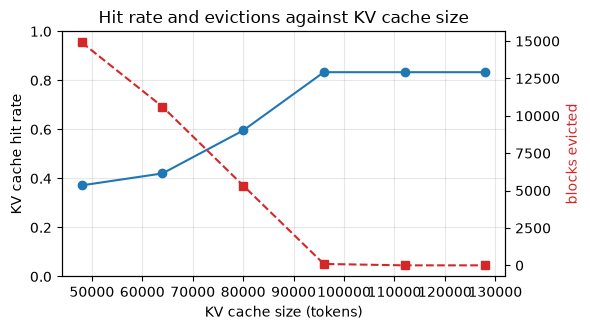

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(cache_sweep.index, cache_sweep["KV cache hit rate"], "o-", color="C0")
ax.set(xlabel="KV cache size (tokens)", ylabel="KV cache hit rate", ylim=(0, 1))
ax2 = ax.twinx()
ax2.plot(cache_sweep.index, cache_sweep["evictions"], "s--", color="C3")
ax2.set_ylabel("blocks evicted", color="C3")
ax2.grid(False)
ax.set_title("Hit rate and evictions against KV cache size")
fig.tight_layout()

KV cache가 약 96,000 token보다 크면, 살아 있는 모든 session의 기록을 담을 수 있어서
eviction이 사실상 멈추고 KV cache hit rate는 83% 그대로입니다. 그 아래에서는 turn 사이에
block이 버려지고 다시 계산되어야 합니다. 48,000 token에서는 hit rate가 37%까지 떨어지고,
tail TTFT는 96,000일 때보다 30배 넘게 나빠집니다. Evict된 session들이 자기 기록 전체를 다시
prefill하면서 서로를 밀어내기 때문입니다. 비좁은 cache라도 없는 것보다는 낫습니다. 중앙값
TTFT는 cache 없는 행보다 네 배 낮으니까요. 다만 tail은 거의 비슷합니다.

여기서도, 가장 오래 안 쓰인 캐시 block을 그냥 **버리는** 우리 simulator와 달리, 많은 실제
시스템은 그것을 **CPU 메모리나 SSD로 흘려보내고**(vLLM의 offloading, LMCache, Mooncake의
cluster 전역 pool) session이 돌아오면 다시 가져옵니다. 이 분야에는 아직 흥미로운 연구
주제가 많이 남아 있습니다.

## 정리

| | 효과 |
|---|---|
| 무엇이 재사용되나 | 맞아떨어지는 **prefix**의 KV block. token들의 사슬 해시로 이름이 붙는다 |
| 가장 큰 이득 | 한 대화의 뒤쪽 turn들, 그리고 *서로 다른* 사용자들이 공유하는 긴 도입부(system prompt, tool 정의, 붙여 넣은 문서) |
| 누가 공유하나 | 같은 token으로 시작하는 두 요청이라면, 같은 사용자든 아니든 |
| TTFT에 대한 효과 | prompt에서 계산되는 부분이 대화 길이와 무관해진다 |
| TPOT / decode에 대한 효과 | 간접적일 뿐 (step당 prefill chunk가 더 적고 더 짧아짐) |
| 무엇이 망치나 | 공유 텍스트 앞에 놓인 가변 텍스트, 메모리 압박에 따른 eviction |
| 무엇과 얽히나 | chunk size, KV cache 용량, 실행 중인 요청이 필요로 하는 메모리 양 |

## 연습문제

:::{admonition} 직접 해보기
:class: exercise
각 문제는 위의 코드를 바꿔서 다시 돌려 보는 것입니다. 돌리기 *전에* 먼저 예상을
적어 보세요.

1. **Replica가 얼마나 더 많은 부하를 감당할 수 있나?** Prompt token의 83%가 사라지지만,
   prefill은 전체 작업의 일부일 뿐입니다. `chat40`에서 caching을 끄고 켜며 `qps`를 1에서
   8까지 쓸어 보고, 각각 p99 TTFT를 2초 아래로 유지하는 가장 높은 도착률을 찾아보세요
   (2강의 goodput 개념). 개선 폭이 83% 근처라도 되나요? 그 차이를 설명해 보세요.
2. **Block 단위.** `chat_trace`는 `block_size=16`(vLLM 기본값)으로 씁니다. Trace를
   32(TensorRT-LLM의 값)와, 과장해서 256으로 다시 만들어 hit rate를 비교해 보세요. 굵은
   block에서 더 많이 손해 보는 쪽은 여러 turn짜리 workload인가요, 공유 preamble
   workload인가요? Block을 메모리 계층 사이로 옮기는 이야기를 떠올리면, 그래도 큰 block을
   원할 이유는 무엇일까요?
3. **시끄러운 이웃.** `chat40`에, prompt가 길고(3,000 token) 다른 어떤 것과도 아무것도
   공유하지 않는 session을 몇 개 더해 보세요. 두 번째 tenant처럼요. 그 혼합을
   `kv_blocks=6000`에서 돌려 보세요. 대화 40개만 있을 때는 eviction이 거의 없던
   지점입니다. 평범한 대화들은 hit rate를 얼마나 잃나요? 그리고 시끄러운 session이 몇 개만
   있어도 문제가 되나요? 이는 한 replica에서 여러 tenant를 서비스하는 것에 대해 무엇을
   말해 주나요?
4. **Caching이 최적 chunk size를 바꾸나?** 3강의 `chunk_size` sweep(128, 512, 2048)을
   `chat40`에서 caching을 끄고 켜며 반복해 보세요. 최적 chunk size가 달라지나요?
:::

## 이해도 확인

답을 눌러 확인하세요. 틀리면 다시 시도할 수 있습니다.

In [8]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Why is the KV cache split into fixed-size blocks instead of one contiguous array per request?",
     "options": ["To make the block hashes cheaper to compute",
                 "Because a request's length is not known in advance, so a contiguous reservation has to be sized for the worst case and most of it is then wasted",
                 "Because a GPU cannot address more than 16 tokens at a time"],
     "answer": 1,
     "explain": "This is PagedAttention (<a href=\"https://arxiv.org/abs/2309.06180\">Kwon et al., SOSP '23</a>): blocks need not be adjacent, so a request over-allocates by at most one block. Giving those blocks names is what makes prefix reuse possible on top of it."},
    {"q": "Why does reusing a cached KV block not change the model's output?",
     "options": ["The error is small enough to ignore",
                 "A token's keys and values depend only on the tokens before it, so the cached values are exactly what a fresh prefill would compute",
                 "The cache is only used for tokens the model has already answered about"],
     "answer": 1,
     "explain": "Attention is causal: the KV of token i is a function of tokens 0..i. If the prefix is identical, the KV is identical."},
    {"q": "Two prompts are identical except for a session id in the <b>first</b> 10 tokens. How much do they share in the cache?",
     "options": ["Everything after the session id", "Nothing", "Half"], "answer": 1,
     "explain": "A block's hash chains in the hash of the previous block, so a difference anywhere early gives every later block a different name."},
    {"q": "In the multi-turn experiment, which turn benefits least from prefix caching?",
     "options": ["The first turn", "The last turn", "All turns benefit equally"], "answer": 0,
     "explain": "Turn 0's prompt has never been seen, so it is a full miss. Later turns reuse everything up to the previous answer."},
    {"q": "An application puts a timestamp at the top of its system prompt. What is the likely effect?",
     "options": ["Nothing; the timestamp is tiny",
                 "The KV cache hit rate across users collapses, because the shared text that follows now hashes differently for every request",
                 "TPOT gets worse"],
     "answer": 1,
     "explain": "Size is irrelevant: it is position that matters. Variable text at the top invalidates the prefix for everything after it."},
    {"q": "Why did the KV cache hit rate fall when we shrank the KV cache?",
     "options": ["Smaller caches hash blocks differently",
                 "Cached blocks are evicted to make room for running requests, so a returning turn no longer finds its prefix",
                 "Prefix caching turns itself off below a memory threshold"],
     "answer": 1,
     "explain": "Cached prefixes and live requests share one pool. Under pressure the least recently used cached blocks are evicted, and the next turn has to recompute them."},
    {"q": "Why do production systems keep evicted KV blocks in CPU memory or on SSD instead of dropping them?",
     "options": ["To survive a GPU crash",
                 "Because fetching a prefix back is roughly an order of magnitude cheaper than prefilling it again",
                 "Because CPU memory is faster than HBM"],
     "answer": 1,
     "explain": "A 9,000-token prefix is ~2.3 GB here: a second or two to recompute, under a tenth of a second to transfer. For short prefixes the comparison flips, which is why the decision is made per request."},
    {"q": "A RAG application retrieves the same ten documents for two users, but in a different order. How much does strict prefix caching reuse?",
     "options": ["All ten documents", "Only up to the first document that differs", "Nothing, ever"],
     "answer": 1,
     "explain": "Prefix matching stops at the first difference, so a reordering destroys almost all of it. Systems like Prompt Cache and CacheBlend relax this, at the price of approximating the attention the chunks never paid to each other."},
    {"q": "A workload has 200-token prompts and 2,000-token answers. How much should prefix caching help?",
     "options": ["A lot: 2,200 tokens are cached",
                 "Very little: almost all the work is decode, which prefix caching cannot skip"],
     "answer": 1,
     "explain": "Only prompt tokens can be reused. Prefix caching pays off when prompts are long and repetitive, which is exactly the agentic workload of the next lecture."},
])

1. KV cache를 요청당 하나의 연속된 배열이 아니라 고정 크기 block으로 쪼개는 이유는? block 해시를 더 싸게 계산하려고 요청의 길이를 미리 알 수 없어서, 연속된 공간을 잡으려면 최악의 경우에 맞춰야 하고 그 대부분이 낭비되므로 GPU가 한 번에 16 token까지만 주소를 지정할 수 있어서 2. 캐시된 KV block을 재사용해도 모델의 출력이 달라지지 않는 이유는? 오차가 무시할 만큼 작아서 한 token의 key와 value는 그 앞 token들에만 의존하므로, 캐시된 값이 새로 prefill했을 때와 정확히 같아서 cache는 모델이 이미 답한 token에만 쓰이므로 3. 두 prompt가 맨 앞 10 token의 session id만 다르고 나머지는 같습니다. cache에서 얼마나 공유될까요? session id 뒤의 전부 아무것도 절반 4. 여러 turn 실험에서 prefix caching의 이득이 가장 적은 turn은? 첫 turn 마지막 turn 모든 turn이 똑같이 이득 5. 어떤 application이 system prompt 맨 앞에 timestamp를 넣었습니다. 어떤 일이 벌어질까요? timestamp는 아주 짧으니 아무 일도 없다 뒤따르는 공유 텍스트가 요청마다 다른 해시를 갖게 되어, 사용자들 사이의 KV cache hit rate가 무너진다 TPOT이 나빠진다 6. KV cache를 줄였을 때 KV cache hit rate가 떨어진 이유는? cache가 작으면 block 해시가 달라져서 실행 중인 요청에게 자리를 내주려고 캐시된 block이 evict되어, 돌아온 turn이 자기 prefix를 더 이상 찾지 못해서 메모리가 일정 수준 아래면 prefix caching이 스스로 꺼져서 7. 실제 시스템이 evict된 KV block을 버리지 않고 CPU 메모리나 SSD에 두는 이유는? GPU가 죽어도 살아남게 하려고 prefix를 다시 가져오는 것이 다시 prefill하는 것보다 대략 한 자릿수 더 싸기 때문에 CPU 메모리가 HBM보다 빨라서 8. 어떤 RAG application이 두 사용자에게 같은 문서 열 개를 서로 다른 순서로 넣어 줍니다. 엄격한 prefix caching은 얼마나 재사용할까요? 문서 열 개 전부 처음으로 달라지는 문서 직전까지만 아무것도, 절대 9. Prompt가 200 token이고 답변이 2,000 token인 workload가 있습니다. prefix caching이 얼마나 도움이 될까요? 아주 많이. 2,200 token이 캐시되니까 거의 안 된다. 일의 대부분이 decode인데, prefix caching은 그것을 건너뛸 수 없다